Заревич Михаил, 513-2

In [ ]:
import pandas as pd
import numpy as np
import itertools
import scipy.stats
import math
import matplotlib.pyplot as plt


Документация на pandas.DataFrame https://pandas.pydata.org/pandas-docs/stable/reference/frame.html

Документация на scipy
https://docs.scipy.org/doc/scipy/index.htm

Статистические функции
https://docs.scipy.org/doc/scipy/tutorial/stats.html

Биномиальное распределение https://docs.scipy.org/doc/scipy/tutorial/stats/discrete_binom.html

Распределение Пуассона https://docs.scipy.org/doc/scipy/tutorial/stats/discrete_poisson.html

Нормальное распределение https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm
https://pieriantraining.com/working-with-scipy-stats-norm-a-guide/


In [ ]:
# Количество экспериментов и шаг увеличения
Nmin = 10
Nmax = 1000
step = 10

# список с количествами экспериментов
ExperimentsNumber = [i for i in range(Nmin, Nmax+1, step)]

# вероятности успеха
prob = [0.0005, 0.005, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.995, 0.9995]

In [ ]:
print(ExperimentsNumber)

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000]


In [ ]:
# для каждого количества должно быть 10 вероятностей
# experiments number, probability
# создаёт пары вида: количество экспериментов, вероятность успеха
ExNumberProb = itertools.product(ExperimentsNumber, prob)



In [ ]:
ColumnNames = [ "Количество опытов, n", "Количество успехов, m", "Вероятность успеха, p", "Вероятность P(X=m) по формуле Бернулли",
                "Вероятность P(X=m) по формуле Пуассона", "Вероятность P(X=m) по формуле нормального распределения",
                "Относительная погрешность биномиального относительно Пуассона", "Относительная погрешность биномиального относительно нормального", "Относительная погрешность Пуассона относительно нормального"]

Код, который всё считает и создаёт датафрейм.

In [ ]:
# список из словарей для создания датафрейма
results = []

# пары вида: количество экспериментов, вероятность успеха
# например 10 0.0005
for n, p in ExNumberProb:

    q = 1-p

    # математическое ожидание
    mean = n*p
    # дисперсия
    variance = n*p*q

    # биномиальное распределение
    # binomial distribution
    bd = scipy.stats.binom(n, p)

    # распределение Пуассона
    # Poisson distribution
    # не pd, так как это отвечает за pandas
    poisd = scipy.stats.poisson(mean)

    # нормальное распределение с мат. ожиданием np и ско npq. Второй параметр тут - ско, а не дисперсия
    # normal distribution
    nd = scipy.stats.norm(mean, math.sqrt(variance))

    # i - количество успехов.
    # для 10 опытов это будет от 0 до 10 включительно
    #success number
    for i in range(n+1):

        # вероятности
        # pmf - probability mass function - функция вероятности, для дискретных СВ
        # pdf - probability dencity function - плотность вероятности, для непрерывных СВ
        bd_prob = bd.pmf(i)
        poisd_prob = poisd.pmf(i)
        nd_prob = nd.pdf(i)

        # Более быстрый вариант, который мне показала Софья.
        # Заносить данные в словарь, потом создавать датафрейм из словаря. Таким образом код выполнится примерно за 4 минуты.
        # создание словаря с полученными данными
        data=[n, i, p, bd_prob, poisd_prob, nd_prob, abs((bd_prob-poisd_prob)/bd_prob), abs((bd_prob-nd_prob)/bd_prob), abs((poisd_prob-nd_prob)/poisd_prob)]
        temp = dict(zip(ColumnNames, data))
        results.append(temp)

        # Неправильный вариант.
        # Добавлять данные в датафрейм сразу. Этот вариант выполняется за 29 минут.
        #data=[[n], [i], [p], [bd_prob], [poisd_prob], [nd_prob],  [abs(bd_prob-poisd_prob)], [abs(bd_prob-nd_prob)], [abs(poisd_prob-nd_prob)],[(bd_prob+poisd_prob+nd_prob)/3]]
        # добавляет данные в датафрейм
        #newdf = pd.DataFrame(temp)
        #df = pd.concat([df,newdf], ignore_index=True,  axis = 0)

# создание датафрейма на основе списка словарей.
df = pd.DataFrame(results)


/tmp/ipython-input-552720643.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  data=[n, i, p, bd_prob, poisd_prob, nd_prob, abs((bd_prob-poisd_prob)/bd_prob), abs((bd_prob-nd_prob)/bd_prob), abs((poisd_prob-nd_prob)/poisd_prob)]
/tmp/ipython-input-552720643.py:43: RuntimeWarning: invalid value encountered in scalar divide
  data=[n, i, p, bd_prob, poisd_prob, nd_prob, abs((bd_prob-poisd_prob)/bd_prob), abs((bd_prob-nd_prob)/bd_prob), abs((poisd_prob-nd_prob)/poisd_prob)]
/tmp/ipython-input-552720643.py:43: RuntimeWarning: overflow encountered in scalar divide
  data=[n, i, p, bd_prob, poisd_prob, nd_prob, abs((bd_prob-poisd_prob)/bd_prob), abs((bd_prob-nd_prob)/bd_prob), abs((poisd_prob-nd_prob)/poisd_prob)]


In [ ]:
df

,"Количество опытов, n","Количество успехов, m","Вероятность успеха, p",Вероятность P(X=m) по формуле Бернулли,Вероятность P(X=m) по формуле Пуассона,Вероятность P(X=m) по формуле нормального распределения,Относительная погрешность биномиального относительно Пуассона,Относительная погрешность биномиального относительно нормального,Относительная погрешность Пуассона относительно нормального
0,10,0,0.0005,9.950112e-01,9.950125e-01,5.629209e+00,0.000001,4.657433,4.657426
1,10,1,0.0005,4.977545e-03,4.975062e-03,5.417331e-43,0.000499,1.000000,1.000000
2,10,2,0.0005,1.120508e-05,1.243766e-05,6.527934e-173,0.110002,1.000000,1.000000
3,10,3,0.0005,1.494758e-08,2.072943e-08,0.000000e+00,0.386808,1.000000,1.000000
4,10,4,0.0005,1.308567e-11,2.591178e-11,0.000000e+00,0.980164,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...
505995,1000,996,0.9995,1.572995e-03,1.256260e-02,2.683891e-06,6.986424,0.998294,0.999786
505996,1000,997,0.9995,1.261551e-02,1.259410e-02,1.086014e-03,0.001697,0.913914,0.913768
505997,1000,998,0.9995,7.580683e-02,1.261303e-02,5.941311e-02,0.833616,0.216257,3.710454
505998,1000,999,0.9995,3.033791e-01,1.261934e-02,4.394462e-01,0.958404,0.448505,33.823223


In [ ]:
# Сохраню этот файл себе, чтобы потом не считать всё снова.
df.to_csv("ТВиМС 2 работа, датафрейм.csv", sep=',', encoding='utf-8') # 67.5 мб
df.to_excel("ТВиМС 2 работа, датафрейм.xlsx") # 39.6 мб

Exception ignored in: <function ZipFile.__del__ at 0x78a41a868c20>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


 Определите попарную относительную погрешность для каждого способа и каждого p. Запишите полученные результаты в
DataFrame. Определите среднюю погрешность и её исправленное среднее квадратическое отклонение для каждой пары n, p.

In [ ]:
# Перед тем, как посчитать погрешность, нужно убрать везде inf
# которые возникли из-за того, что, например, для данных вероятностей
# приближение неприменимо, поэтому разброс получился слишком большим
# Если этого не сделать, mean и std тоже будет равно бесконечности.
df_clean_no_inf = df.replace([np.inf, -np.inf], np.nan)

# В этой таблице всё ещё могут быть некоторые inf
# Они возникли из-за того, что некоторые вероятности получились очень маленькими
# т.е у биномиального 1e-50 а у Пуассона 1e-10. Разница между ними, соответственно, очень большая.
# Поэтому где-то тут возникала ошибка RuntimeWarning: overflow encountered in square sqr = _ensure_numeric((avg - values) ** 2)
# говорящая о том, что значение для числового типа данных оказалось слишком большим и оно было переведено в inf
# Чтобы это исправить, нужно убрать слишком маленькие значения
df_clean_clear_no_small_prob= df_clean_no_inf[df_clean_no_inf['Вероятность P(X=m) по формуле Бернулли'] > 1e-10]


# Группировка по арам n и p, и для колонок с погрешностями считаем mean (средняя погрешность) и std (СКО)
error_df = df_clean_clear_no_small_prob.groupby(['Количество опытов, n', 'Вероятность успеха, p'])[[
    'Относительная погрешность биномиального относительно Пуассона',
    'Относительная погрешность биномиального относительно нормального',
     "Относительная погрешность Пуассона относительно нормального"
]].agg(['mean', 'std'])

# Выводим результат
error_df.to_excel("ТВиМС 2 работа, cтатистика погрешностей.xlsx")

error_df

Относительная погрешность биномиального относительно Пуассона  \
                                                                                                    mean   
Количество опытов, n Вероятность успеха, p                                                                 
10                   0.0005                                                      1.243275e-01              
                     0.0050                                                      6.073193e-01              
                     0.0500                                                      5.907114e+00              
                     0.2500                                                      2.412319e+01              
                     0.5000                                                      2.823457e+00              
...                                                                                       ...              
1000                 0.7500                                                      4.616520e+04              
                     0.9000                                                      5.452948e+05              
                     0.9500                                                      1.014757e+06              
                     0.9950                                                      4.697561e+06              
                     0.9995                                                      7.397846e+06              

                                                          \
                                                     std   
Количество опытов, n Вероятность успеха, p                 
10                   0.0005                 1.824756e-01   
                     0.0050                 8.692819e-01   
                     0.0500                 1.181979e+01   
                     0.2500                 6.724685e+01   
                     0.5000                 5.200253e+00   
...                                                  ...   
1000                 0.7500                 1.844273e+05   
                     0.9000                 2.276979e+06   
                     0.9500                 4.389943e+06   
                     0.9950                 1.930607e+07   
                     0.9995                 2.320697e+07   

                                           Относительная погрешность биномиального относительно нормального  \
                                                                                                       mean   
Количество опытов, n Вероятность успеха, p                                                                    
10                   0.0005                                                          1.914358                 
                     0.0050                                                          0.971596                 
                     0.0500                                                          0.762704                 
                     0.2500                                                          0.352158                 
                     0.5000                                                          0.163178                 
...                                                                                       ...                 
1000                 0.7500                                                          0.376194                 
                     0.9000                                                          1.453251                 
                     0.9500                                                          5.515071                 
                     0.9950                                                          0.607588                 
                     0.9995                                                          0.804759                 

                                                       \
                                                  std   
Количество опытов, n

# Ответы на контрольные вопросы





## 1 Для каких пар значений n, p применимо приближённое вычисление вероятности при помощи распределения Пуассона?

Распределение Пуассона, вместо биномиального, можно применять, если вероятность успеха p стремится к нулю, а число экспериментов n - к бесконечности.

Убедимся в этом, построив графики биномиального распределения и распределения Пуассона для одних и тех же параметров n и p, а также построим график погрешности между ними.

Из графиков также видно, что приближение хорошо работает в точках, близких к пику биномиального распределения.

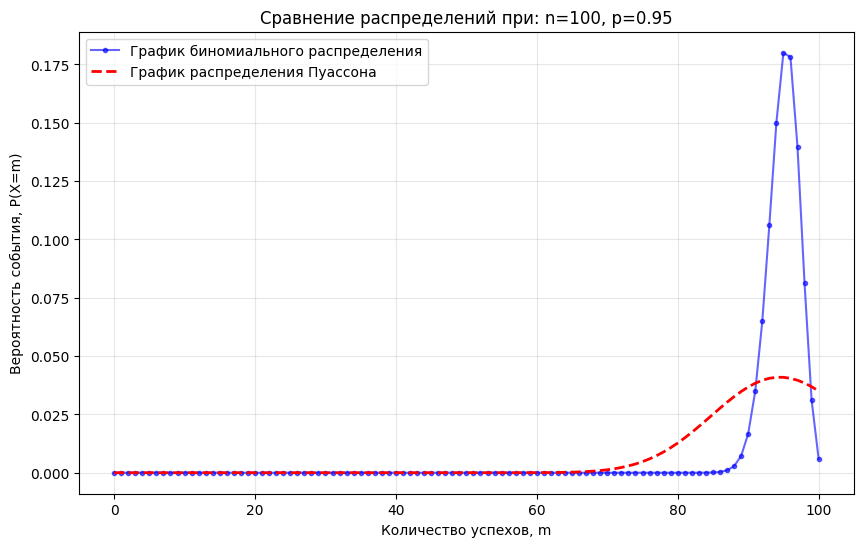

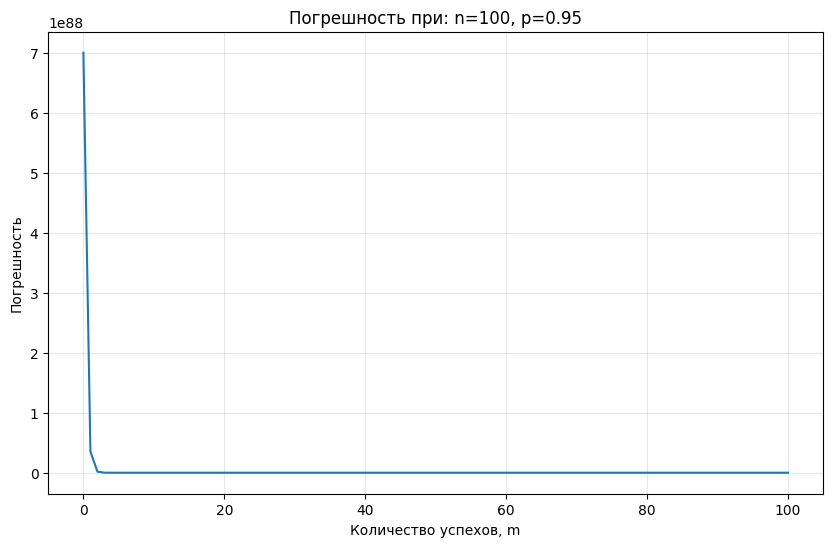

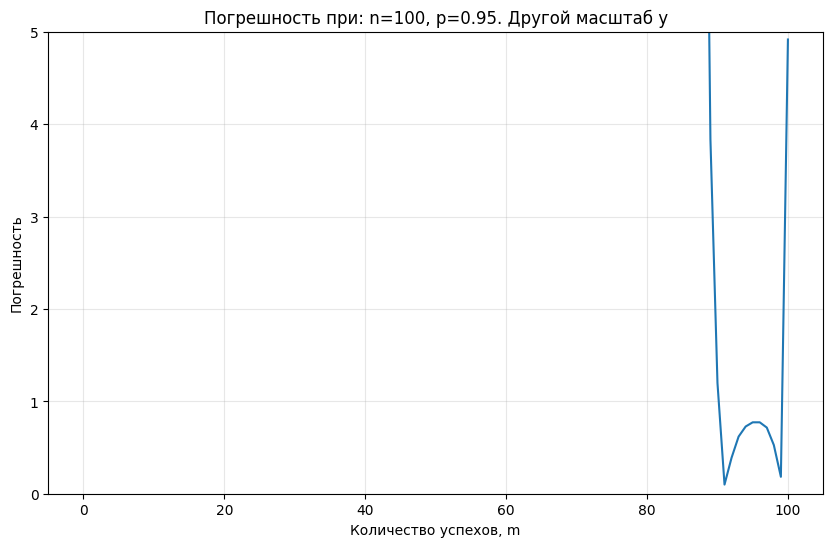

In [51]:
current_n = 100
current_p = 0.95


subset = df_clean_no_inf[(df_clean_no_inf["Количество опытов, n"] == current_n) &
                  (df_clean_no_inf["Вероятность успеха, p"] == current_p)]


#subset = subset.sort_values(by="Количество успехов, m")


plt.figure(figsize=(10, 6))

# График биномиального распределения
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Бернулли"],
         label="График биномиального распределения",
         color="blue", marker="o", markersize=3, alpha=0.6)

# График распределения Пуассона
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Пуассона"],
         label="График распределения Пуассона",
         color="red", linestyle="--", linewidth=2)

plt.title(f"Сравнение распределений при: n={current_n}, p={current_p}")
plt.xlabel("Количество успехов, m")
plt.ylabel("Вероятность события, P(X=m)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# График погрешности
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно Пуассона"] , label="Относительная погрешность биномиального относительно Пуассона при n = 100, p = 0.95")

plt.title(f"Погрешность при: n={current_n}, p={current_p}")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

# В диапазоне от 80 до 100 график пошёл слишком низко, по сравнениию с первыми значениями,
# Поэтому я ограничил значения y, чтобы он был более информативным.
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно Пуассона"] , label="Относительная погрешность биномиального относительно Пуассона при n = 100, p = 0.95")

plt.ylim(0, 5)
plt.grid(True, alpha=0.3)

plt.title(f"Погрешность при: n={current_n}, p={current_p}. Другой масштаб y")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

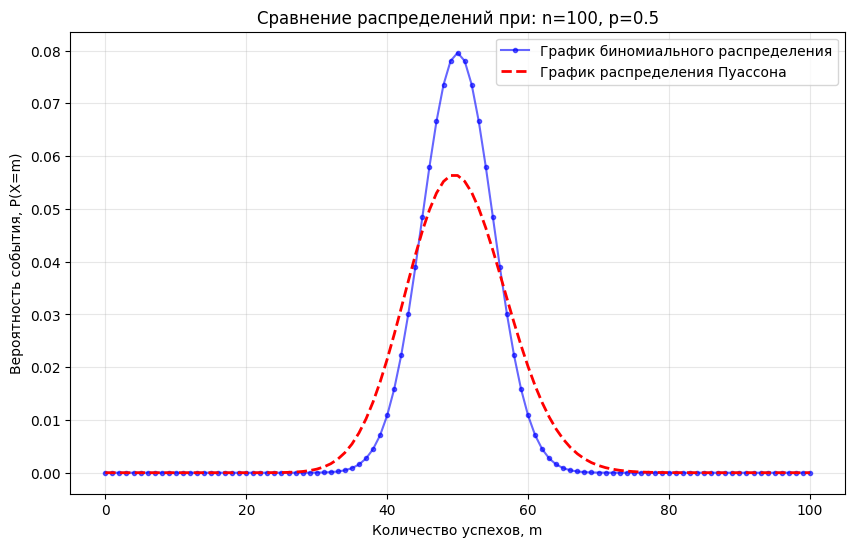

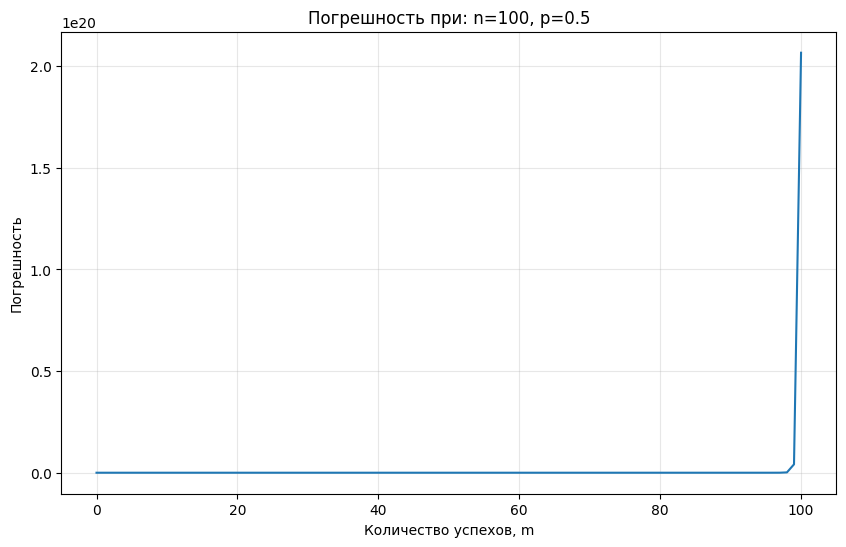

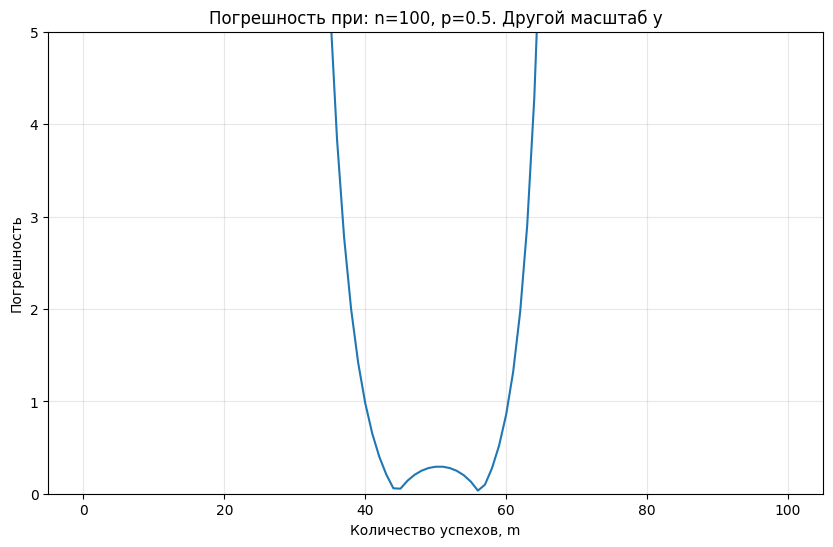

In [52]:
current_n = 100
current_p = 0.5


subset = df_clean_no_inf[(df_clean_no_inf["Количество опытов, n"] == current_n) &
                  (df_clean_no_inf["Вероятность успеха, p"] == current_p)]


#subset = subset.sort_values(by="Количество успехов, m")


plt.figure(figsize=(10, 6))

# График биномиального распределения
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Бернулли"],
         label="График биномиального распределения",
         color="blue", marker="o", markersize=3, alpha=0.6)

# График распределения Пуассона
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Пуассона"],
         label="График распределения Пуассона",
         color="red", linestyle="--", linewidth=2)

plt.title(f"Сравнение распределений при: n={current_n}, p={current_p}")
plt.xlabel("Количество успехов, m")
plt.ylabel("Вероятность события, P(X=m)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# График погрешности
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно Пуассона"] , label="Относительная погрешность биномиального относительно Пуассона при n = 100, p = 0.95")

plt.title(f"Погрешность при: n={current_n}, p={current_p}")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

# В диапазоне от 80 до 100 график пошёл слишком низко, по сравнениию с первыми значениями,
# Поэтому я ограничил значения y, чтобы он был более информативным.
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно Пуассона"] , label="Относительная погрешность биномиального относительно Пуассона при n = 100, p = 0.95")

plt.ylim(0, 5)
plt.grid(True, alpha=0.3)

plt.title(f"Погрешность при: n={current_n}, p={current_p}. Другой масштаб y")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

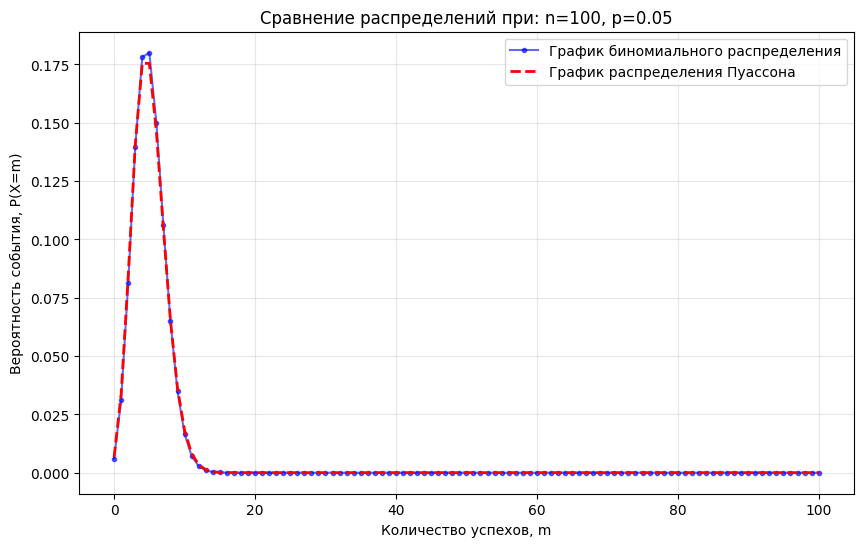

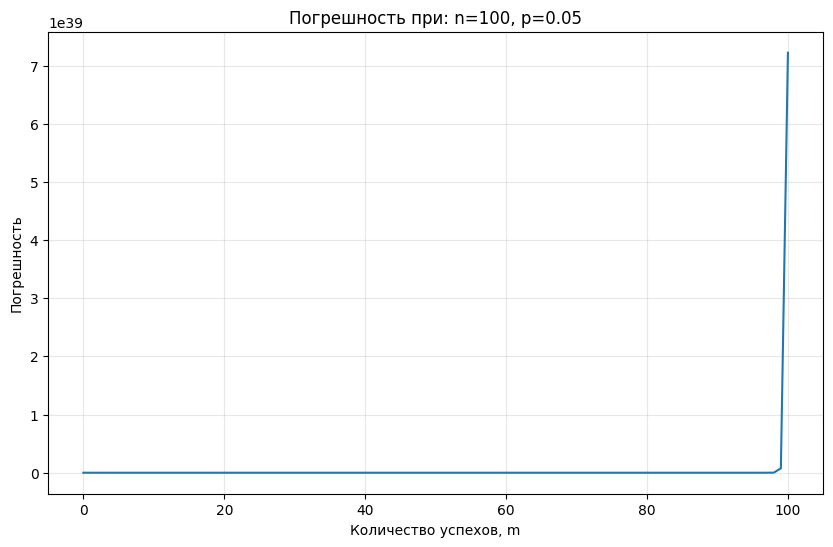

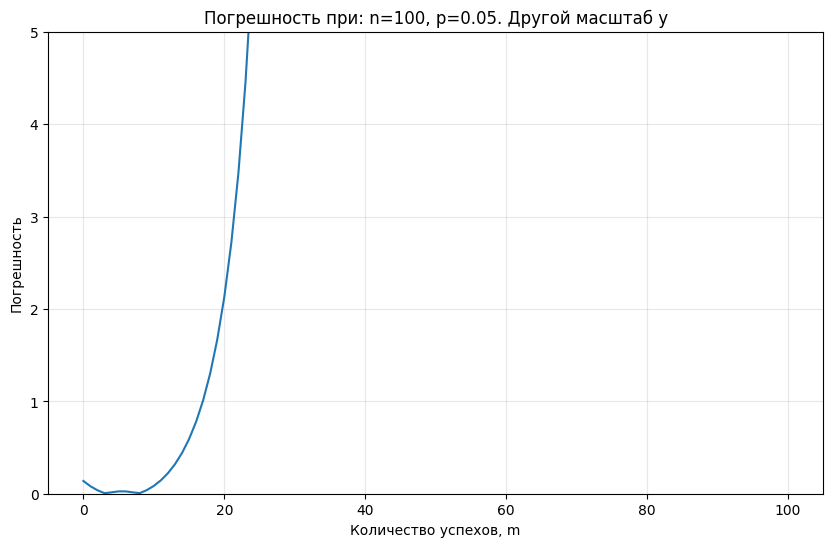

In [53]:


current_n = 100
current_p = 0.05


subset = df_clean_no_inf[(df_clean_no_inf["Количество опытов, n"] == current_n) &
                  (df_clean_no_inf["Вероятность успеха, p"] == current_p)]


#subset = subset.sort_values(by="Количество успехов, m")


plt.figure(figsize=(10, 6))

# График биномиального распределения
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Бернулли"],
         label="График биномиального распределения",
         color="blue", marker="o", markersize=3, alpha=0.6)

# График распределения Пуассона
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Пуассона"],
         label="График распределения Пуассона",
         color="red", linestyle="--", linewidth=2)

plt.title(f"Сравнение распределений при: n={current_n}, p={current_p}")
plt.xlabel("Количество успехов, m")
plt.ylabel("Вероятность события, P(X=m)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# График погрешности
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно Пуассона"] , label="Относительная погрешность биномиального относительно Пуассона при n = 100, p = 0.95")

plt.title(f"Погрешность при: n={current_n}, p={current_p}")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

# В диапазоне от 80 до 100 график пошёл слишком низко, по сравнениию с первыми значениями,
# Поэтому я ограничил значения y, чтобы он был более информативным.
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]
#df1 = df1[df1["Количество успехов, m"] > 0]
#df1 = df1[df1["Количество успехов, m"] <30]


plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно Пуассона"] , label="Относительная погрешность биномиального относительно Пуассона при n = 100, p = 0.95")

plt.ylim(0, 5)
plt.grid(True, alpha=0.3)

plt.title(f"Погрешность при: n={current_n}, p={current_p}. Другой масштаб y")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

## Второй вариант ответа

Этот вариант списал в нейросети.

Визуализация функции $mean = f(n,p)$ из данных датафрейма error_df

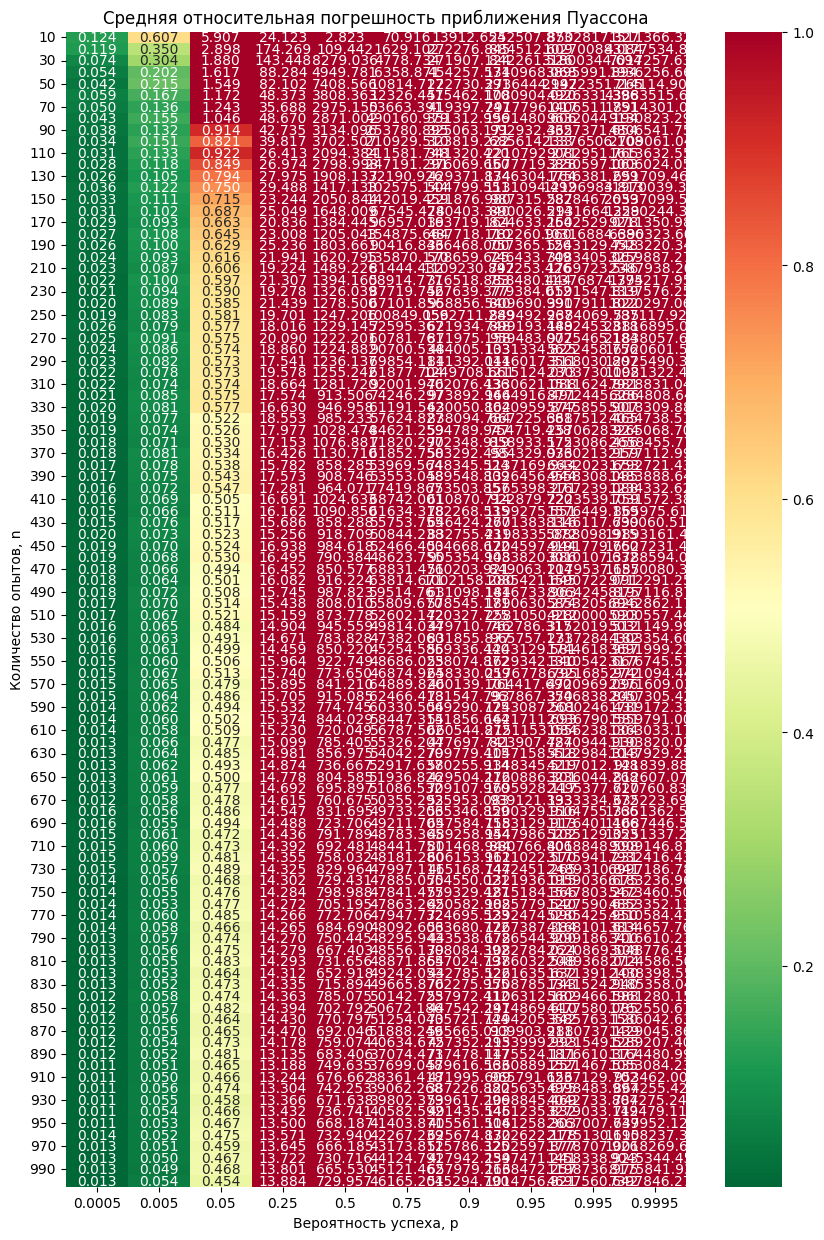

In [ ]:
import seaborn as sns

# Сбрасываем индекс, чтобы n и p стали обычными колонками
viz_data = error_df.reset_index()

# 2. Создаем сводную таблицу для heatmap
# Строки - n, Столбцы - p, Значения - Средняя погрешность
# В values передаем кортеж, чтобы выбрать конкретно среднее значение ('mean')
pivot_table = viz_data.pivot(
    index="Количество опытов, n",
    columns="Вероятность успеха, p",
    values=("Относительная погрешность биномиального относительно Пуассона", "mean")
)

# Рисуем тепловую карту
plt.figure(figsize=(10, 15))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="RdYlGn_r", vmax=1.0)
# vmax=1.0 ограничивает цветовую шкалу: всё, что выше 100% ошибки - красное.
# cmap="RdYlGn_r" - от зеленого (мало ошибок) к красному (много).


plt.title("Средняя относительная погрешность приближения Пуассона")
plt.show()

## 2 Для каких пар значений n, p применимо приближённое вычисление вероятности при помощи локальной теоремы Муавра-Лапласа?

см. Гнеденко, стр 96-97
https://psv4.userapi.com/s/v1/d/6NMy4u3YcDHrFFcPKRzzAcW4_7z4LEgd4Q-FoWYiOUUyp_15sYs0xEiCf_TdMsFYwc_Vlf3zcBsJgaKAI0R3-BaNVb6xgdTK2dNGAdpFcBz8K6tHXAvEYw/Gnedenko_B_V_-_Kurs_teorii_veroyatnostey_Izd.pdf

Число n должно быть достаточно большим, больше нескольких сотен, а p - не слишком близким к нулю или единице. Формула работает тем лучше, чем больше n и чем p ближе к 0,5.

Визуализация функции $mean=f(n,p)$  из данных датафрейма error_df. График подтверждает информацию из учебника.

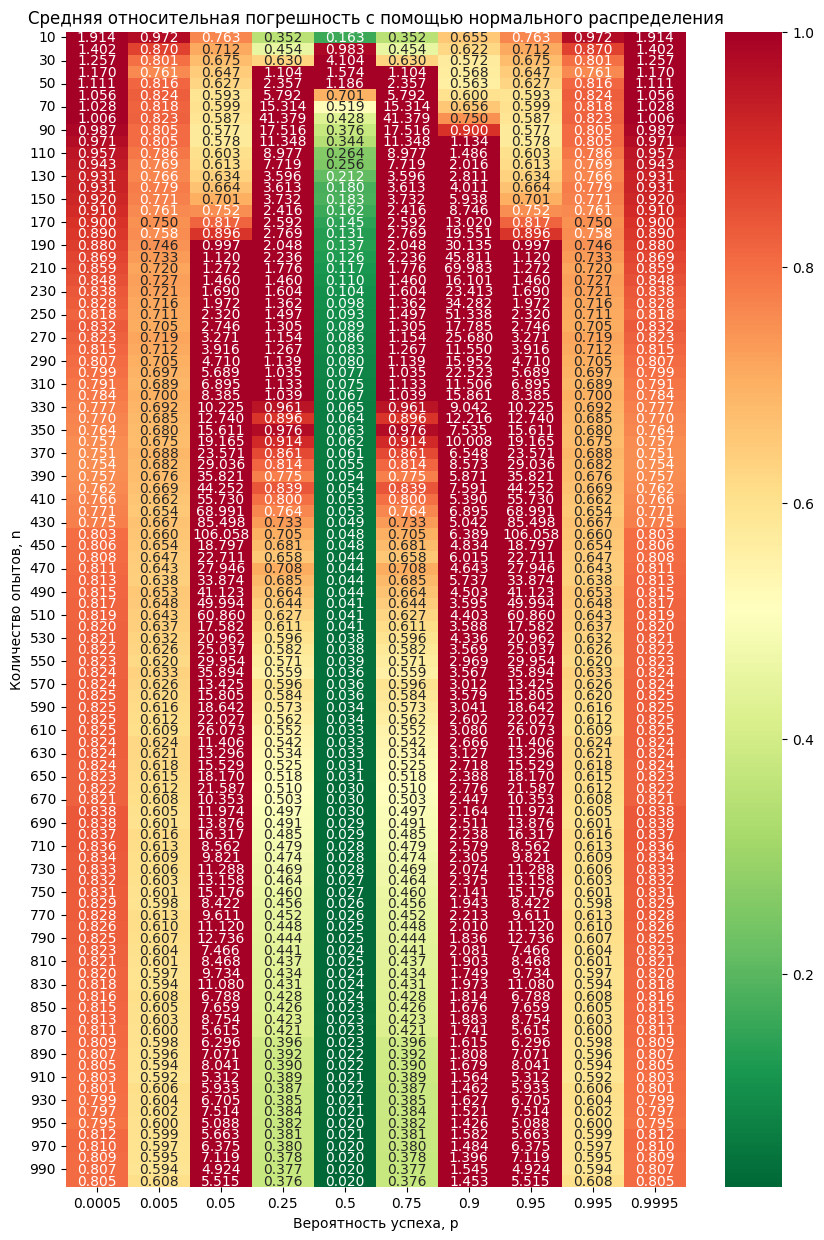

In [58]:
import seaborn as sns

# Сбрасываем индекс, чтобы n и p стали обычными колонками
viz_data = error_df.reset_index()

# 2. Создаем сводную таблицу для heatmap
# Строки - n, Столбцы - p, Значения - Средняя погрешность
# В values передаем кортеж, чтобы выбрать конкретно среднее значение ('mean')
pivot_table = viz_data.pivot(
    index="Количество опытов, n",
    columns="Вероятность успеха, p",
    values=("Относительная погрешность биномиального относительно нормального", "mean")
)

# Рисуем тепловую карту
plt.figure(figsize=(10, 15))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="RdYlGn_r", vmax=1.0)
# vmax=1.0 ограничивает цветовую шкалу: всё, что выше 100% ошибки - красное.
# cmap="RdYlGn_r" - от зеленого (мало ошибок) к красному (много).


plt.title("Средняя относительная погрешность с помощью нормального распределения")
plt.show()

Аналогичные резульаты получаются, если зафиксировать значение n и построить графики для разных p. Видно, что при p = 0.5, погрешность самя низкая.

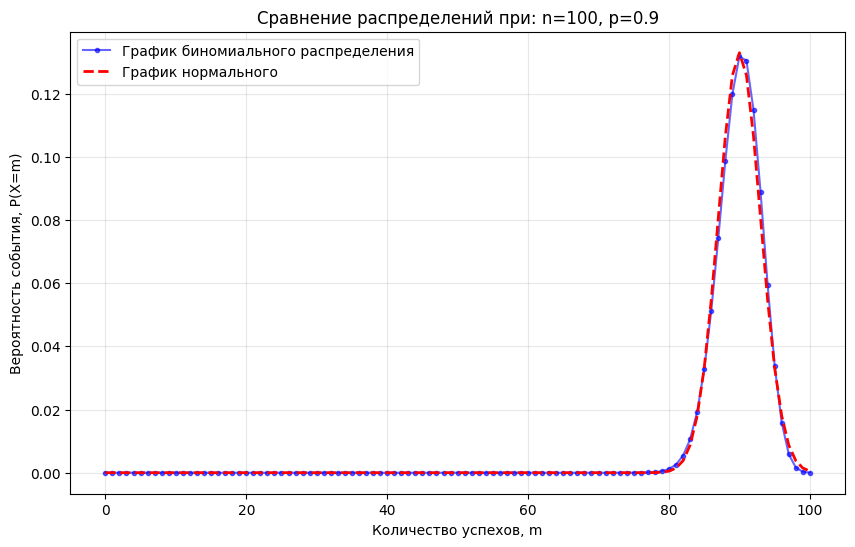

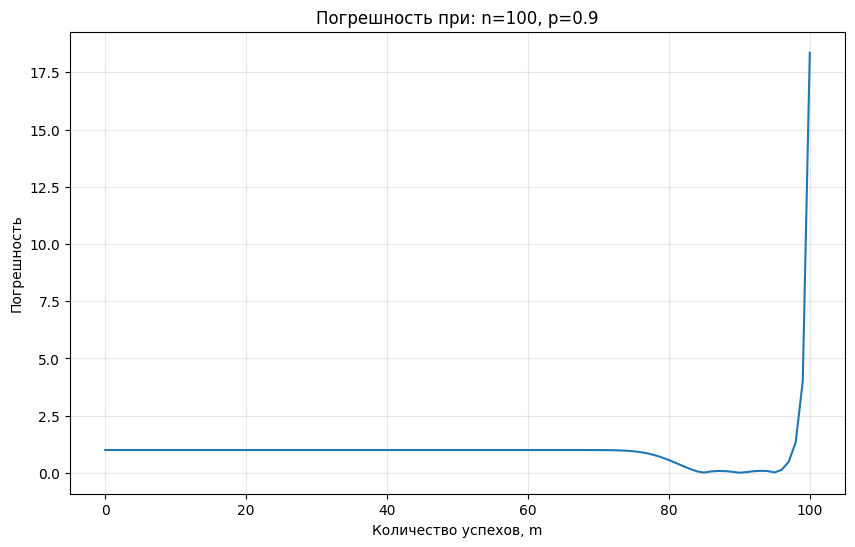

In [74]:
current_n = 100
current_p = 0.90


subset = df_clean_no_inf[(df_clean_no_inf["Количество опытов, n"] == current_n) &
                  (df_clean_no_inf["Вероятность успеха, p"] == current_p)]


#subset = subset.sort_values(by="Количество успехов, m")


plt.figure(figsize=(10, 6))

# График биномиального распределения
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Бернулли"],
         label="График биномиального распределения",
         color="blue", marker="o", markersize=3, alpha=0.6)

# График нормального распределения
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле нормального распределения"],
         label="График нормального",
         color="red", linestyle="--", linewidth=2)

plt.title(f"Сравнение распределений при: n={current_n}, p={current_p}")
plt.xlabel("Количество успехов, m")
plt.ylabel("Вероятность события, P(X=m)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# График погрешности
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно нормального"] , label="Относительная погрешность биномиального относительно нормального при n = 100, p = 0.95")

plt.title(f"Погрешность при: n={current_n}, p={current_p}")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()






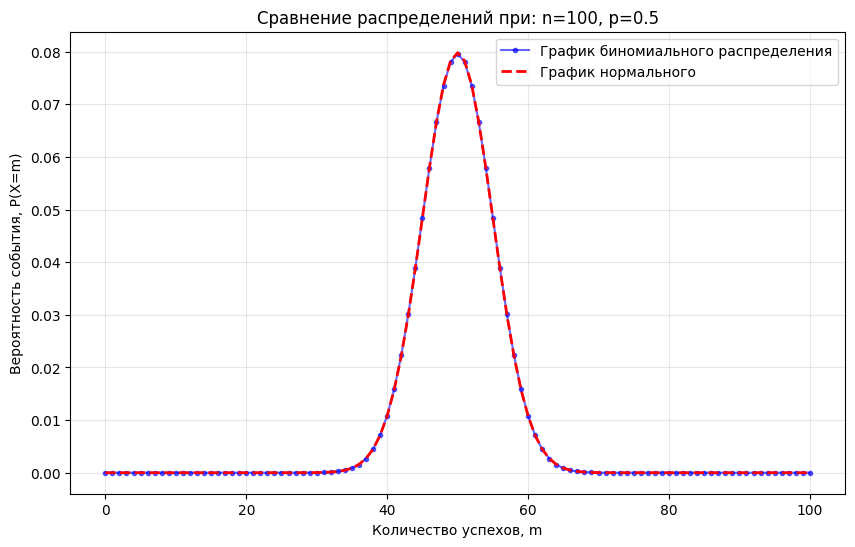

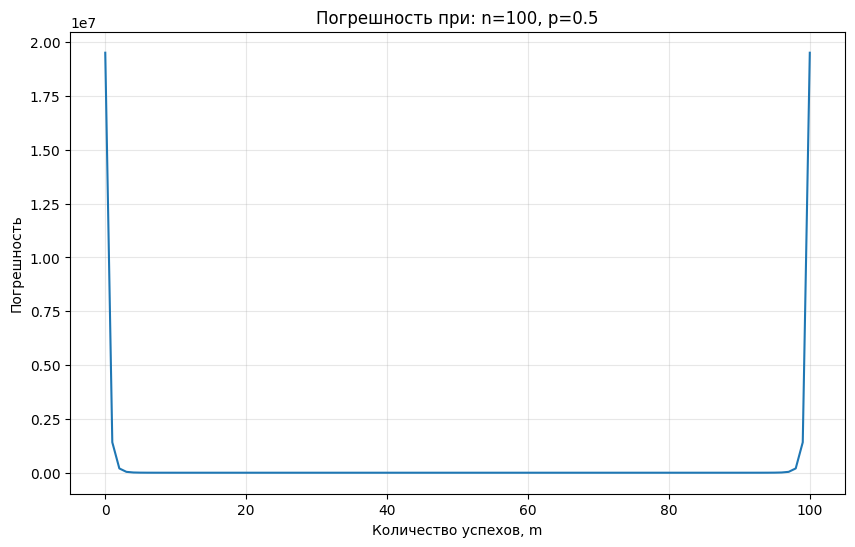

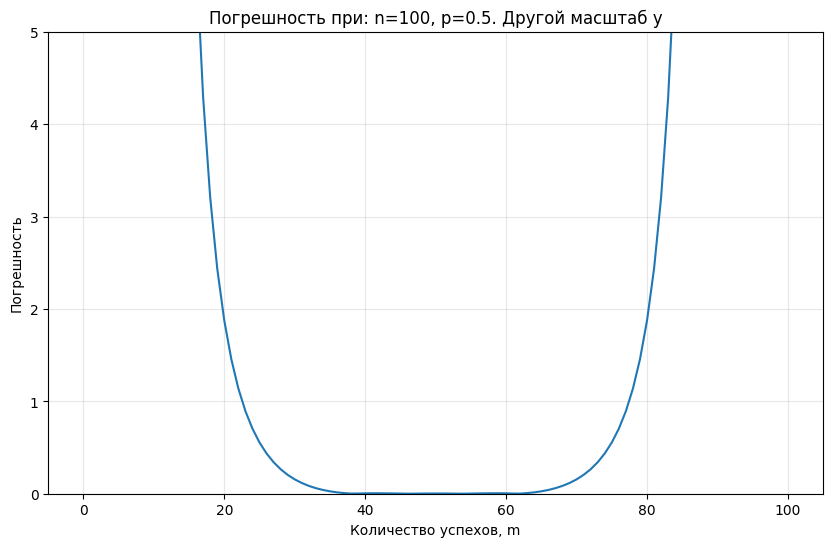

In [64]:
current_n = 100
current_p = 0.5


subset = df_clean_no_inf[(df_clean_no_inf["Количество опытов, n"] == current_n) &
                  (df_clean_no_inf["Вероятность успеха, p"] == current_p)]


#subset = subset.sort_values(by="Количество успехов, m")


plt.figure(figsize=(10, 6))

# График биномиального распределения
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Бернулли"],
         label="График биномиального распределения",
         color="blue", marker="o", markersize=3, alpha=0.6)

# График распределения Пуассона
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле нормального распределения"],
         label="График нормального",
         color="red", linestyle="--", linewidth=2)

plt.title(f"Сравнение распределений при: n={current_n}, p={current_p}")
plt.xlabel("Количество успехов, m")
plt.ylabel("Вероятность события, P(X=m)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# График погрешности
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно нормального"] , label="Относительная погрешность биномиального относительно нормального при n = 100, p = 0.95")

plt.title(f"Погрешность при: n={current_n}, p={current_p}")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

# График с другим масштабом
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно нормального"] , label="Относительная погрешность биномиального относительно нормального при n = 100, p = 0.95")

plt.ylim(0, 5)
plt.grid(True, alpha=0.3)

plt.title(f"Погрешность при: n={current_n}, p={current_p}. Другой масштаб y")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()



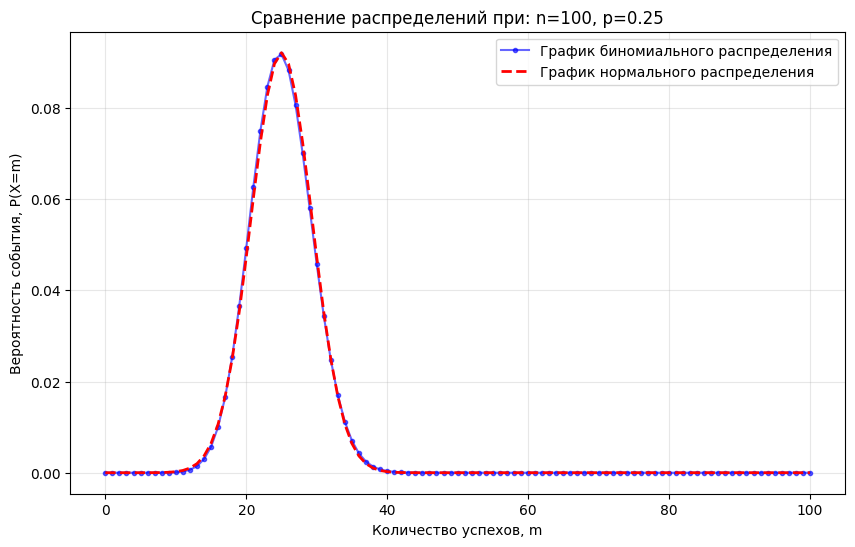

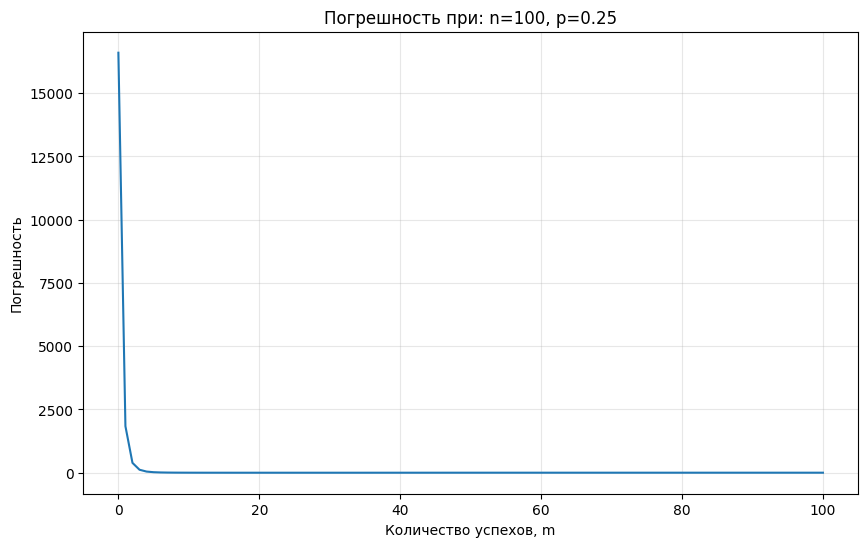

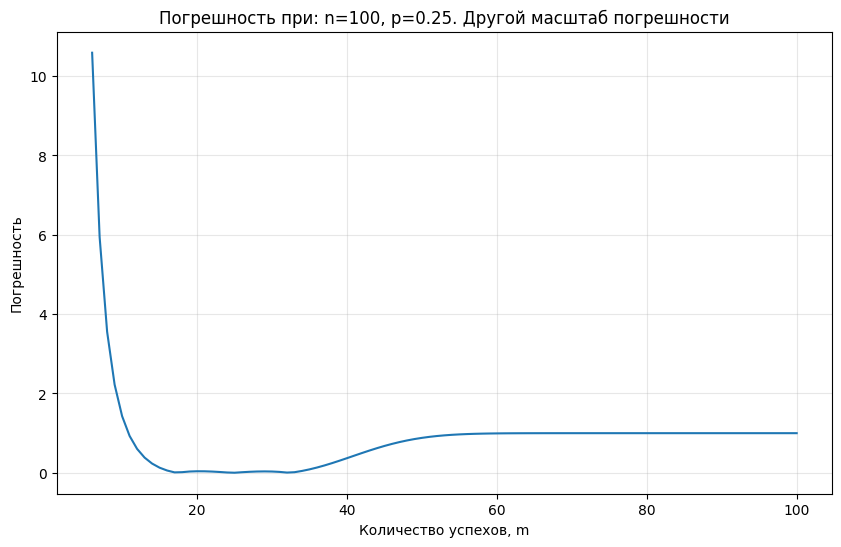

In [84]:
current_n = 100
current_p = 0.25


subset = df_clean_no_inf[(df_clean_no_inf["Количество опытов, n"] == current_n) &
                  (df_clean_no_inf["Вероятность успеха, p"] == current_p)]


#subset = subset.sort_values(by="Количество успехов, m")


plt.figure(figsize=(10, 6))

# График биномиального распределения
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле Бернулли"],
         label="График биномиального распределения",
         color="blue", marker="o", markersize=3, alpha=0.6)

# График распределения Пуассона
plt.plot(subset["Количество успехов, m"],
         subset["Вероятность P(X=m) по формуле нормального распределения"],
         label="График нормального распределения",
         color="red", linestyle="--", linewidth=2)

plt.title(f"Сравнение распределений при: n={current_n}, p={current_p}")
plt.xlabel("Количество успехов, m")
plt.ylabel("Вероятность события, P(X=m)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# График погрешности
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]

plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно нормального"] , label="Относительная погрешность биномиального относительно нормального при n = 100, p = 0.95")

plt.title(f"Погрешность при: n={current_n}, p={current_p}")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()


#
df1 = df_clean_no_inf[df_clean_no_inf["Количество опытов, n"] == current_n]
df1 = df1[df1["Вероятность успеха, p"] == current_p]
df1 = df1[df1["Количество успехов, m"] > 5]


plt.figure(figsize=(10, 6))
plt.plot(df1["Количество успехов, m"], df1["Относительная погрешность биномиального относительно нормального"] , label="Относительная погрешность биномиального относительно нормального при n = 100, p = 0.95")

plt.title(f"Погрешность при: n={current_n}, p={current_p}. Другой масштаб погрешности")

plt.xlabel("Количество успехов, m")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)

plt.show()

## 3 Как влияет на результаты увеличение значения n?

Из хитмапов в заданиях 1 и 2 видно, что с увеличением n погрешность уменьшается.

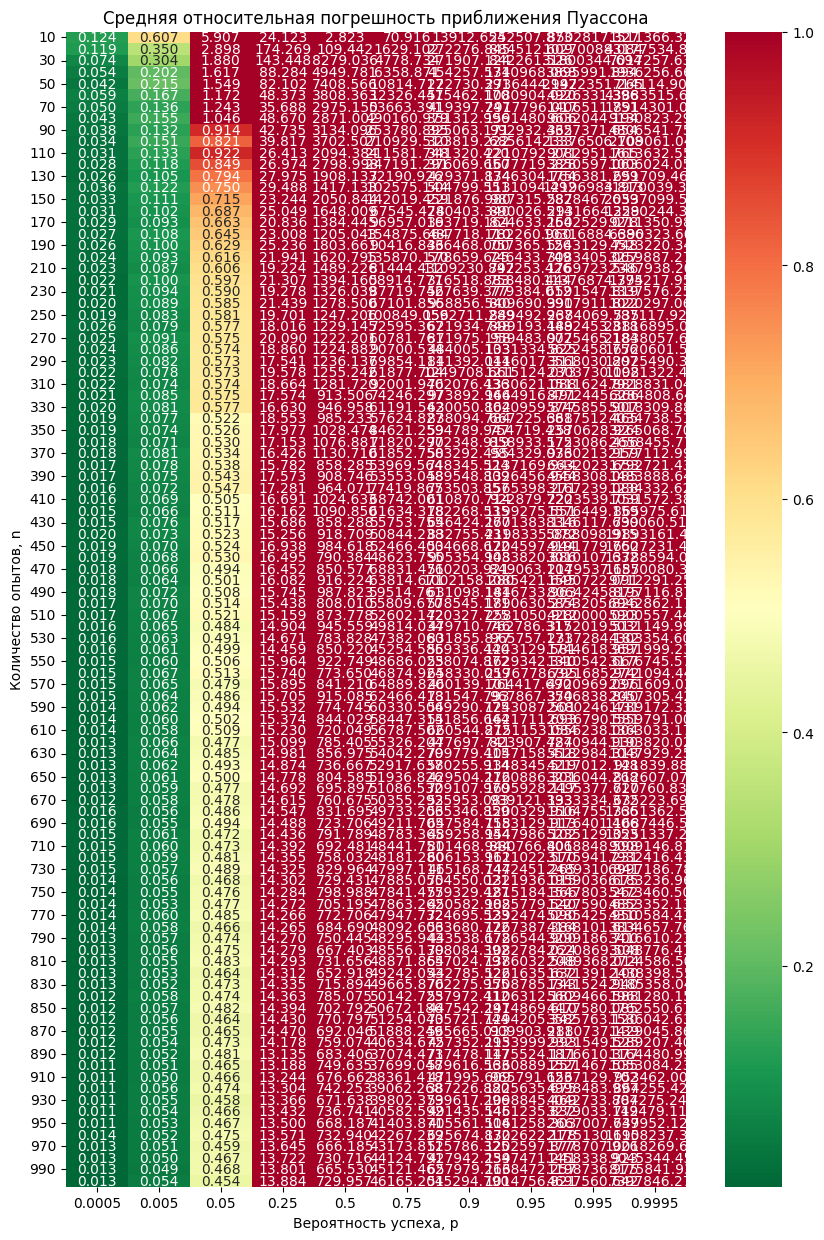

In [87]:
import seaborn as sns

viz_data = error_df.reset_index()

pivot_table = viz_data.pivot(
    index="Количество опытов, n",
    columns="Вероятность успеха, p",
    values=("Относительная погрешность биномиального относительно Пуассона", "mean")
)

plt.figure(figsize=(10, 15))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="RdYlGn_r", vmax=1.0)


plt.title("Средняя относительная погрешность приближения Пуассона")
plt.show()


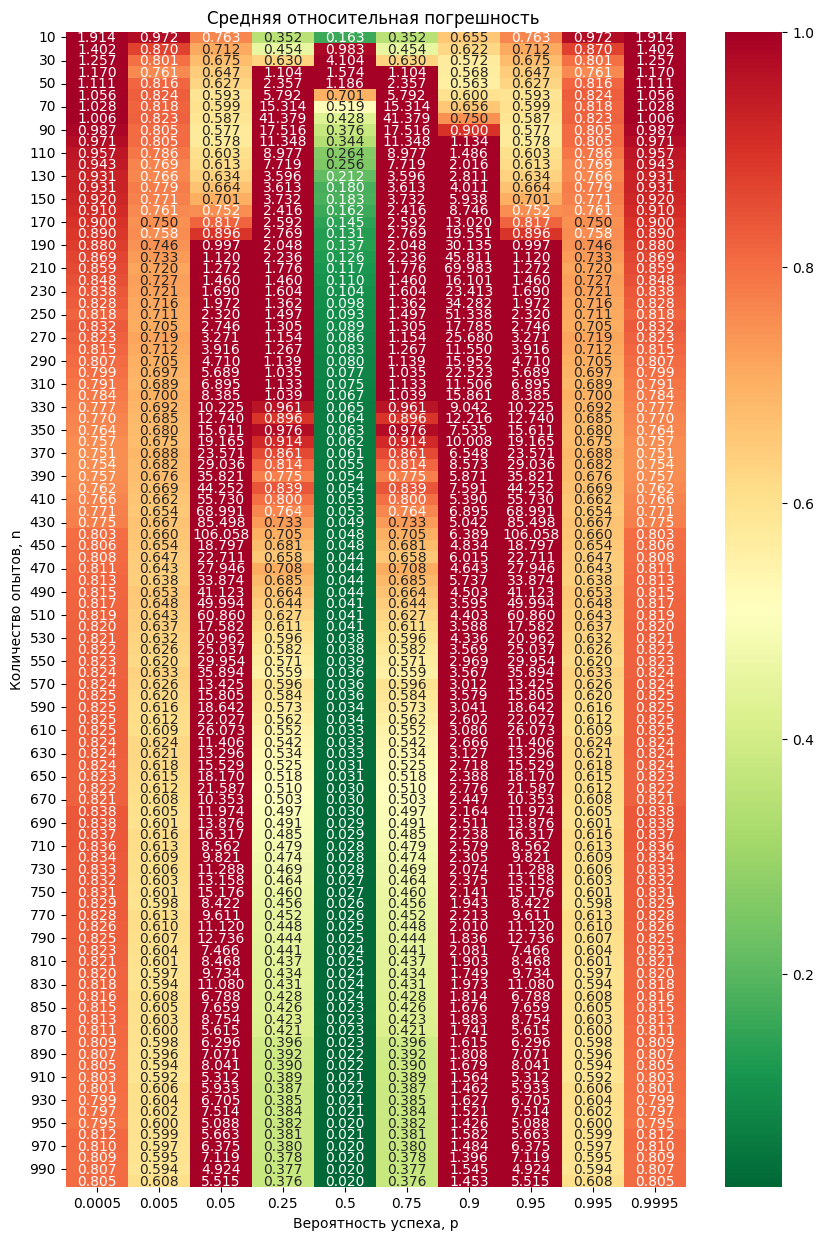

In [88]:
pivot_table = viz_data.pivot(
    index="Количество опытов, n",
    columns="Вероятность успеха, p",
    values=("Относительная погрешность биномиального относительно нормального", "mean")
)

plt.figure(figsize=(10, 15))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="RdYlGn_r", vmax=1.0)


plt.title("Средняя относительная погрешность ")
plt.show()

# Тест. Потом убрать

Эту часть взял у Софьи. Хочу разобраться, что она тут делала.

In [ ]:
df_analysis = df.groupby(['Количество опытов, n', 'Вероятность успеха, p']).agg({
    'Относительная погрешность биномиального относительно Пуассона': ['mean', 'std'],
    'Относительная погрешность биномиального относительно нормального': ['mean', 'std'],
    'Относительная погрешность Пуассона относительно нормального': ['mean', 'std']
}).reset_index()
df_analysis

Количество опытов, n Вероятность успеха, p  \
                                                 
0                     10                0.0005   
1                     10                0.0050   
2                     10                0.0500   
3                     10                0.2500   
4                     10                0.5000   
..                   ...                   ...   
995                 1000                0.7500   
996                 1000                0.9000   
997                 1000                0.9500   
998                 1000                0.9950   
999                 1000                0.9995   

    Относительная погрешность биномиального относительно Пуассона              \
                                                             mean         std   
0                                           281.187718             819.827777   
1                                           268.978872             783.718033   
2                                           172.594595             499.471139   
3                                            24.123191              67.246848   
4                                             2.823457               5.200253   
..                                                 ...                    ...   
995                                                inf                    NaN   
996                                                inf                    NaN   
997                                                inf                    NaN   
998                                                inf                    NaN   
999                                                inf                    NaN   

    Относительная погрешность биномиального относительно нормального  \
                                                                mean   
0                                         1.332494e+00                 
1                                         9.845068e-01                 
2                                         8.058489e-01                 
3                                         3.521577e-01                 
4                                         1.631782e-01                 
..                                                 ...                 
995                                       1.278410e+48                 
996                                       3.091417e+17                 
997                                       9.196954e+06                 
998                                       9.583563e-01                 
999                                       9.861442e-01                 

                  Относительная погрешность Пуассона относительно нормального  \
              std                                                        mean   
0    1.102757e+00                                           1.332493            
1    4.997412e-02                                           0.984484            
2    3.188477e-01                                           0.814012            
3    3.562914e-01                                           0.517760            
4    2.861121e-01                                           0.476070            
..            ...                                                ...            
995  3.640954e+49                                           0.966922            
996  7.344478e+18                                           0.998018            
997  1.882292e+08                                           1.018045            
998  1.841972e-01                                           1.059779            
999  9.606286e-02                                           1.073428            

               
          std  
0    1.102755  
1    0.050043  
2    0.309294  
3    0.374736  
4    0.265750  
..        ...  
995  0.136601  
996  0.153088  
997  0.246917  
998  0.747625  
999  1.524190  

[1000 rows x 8 columns]

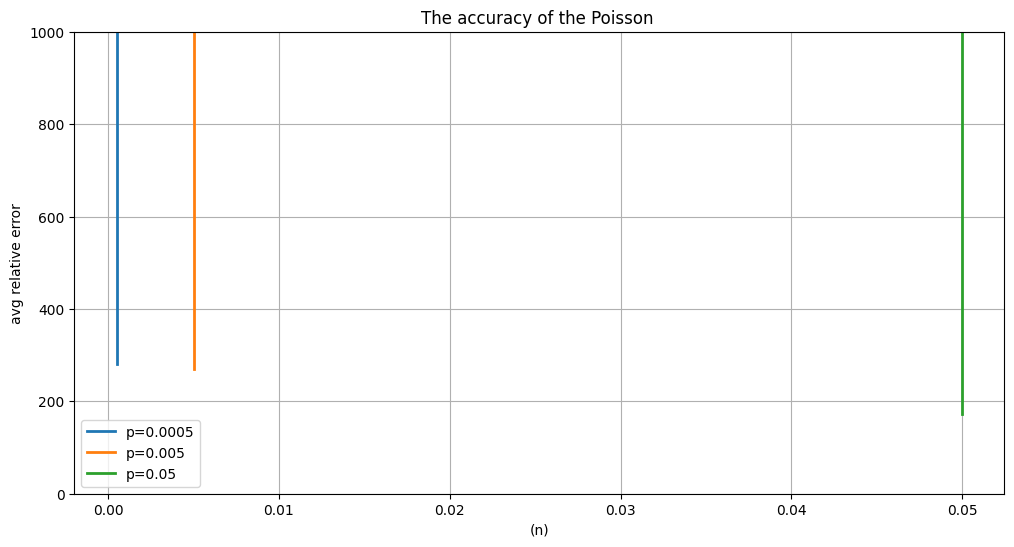

In [ ]:
poisson_p_values = [0.0005, 0.005, 0.05]
poisson_df = df_analysis[df_analysis['Вероятность успеха, p'].isin(poisson_p_values)]

plt.figure(figsize=(12, 6))
for p_val in poisson_p_values:
    subset = poisson_df[poisson_df['Вероятность успеха, p'] == p_val]
    plt.plot(subset['Вероятность успеха, p'], subset[('Относительная погрешность биномиального относительно Пуассона', 'mean')],
             label=f'p={p_val}', linewidth=2)

plt.xlabel('(n)')
plt.ylabel('avg relative error')
plt.title('The accuracy of the Poisson ')
plt.legend()
plt.grid(True)
plt.ylim(0, 1000)
plt.show()

In [ ]:
import math
n = 100
p = 0.8
temp = scipy.stats.binom(n,p)
print(temp.cdf(101))

temp1 = scipy.stats.poisson(n*p)
print(temp1.cdf(1/(n*p)))

# математическое ожидание
mean = n*p
# дисперсия
variance = n*p*(1-p)
# нормальное распределение с мат. ожиданием np и ско npq. Второй параметр тут - ско, а не дисперсия
temp2 = scipy.stats.norm(mean,math.sqrt(variance))
print(temp2.cdf(mean+3*math.sqrt(variance))-temp2.cdf(mean-3*math.sqrt(variance)))




1.0
1.804851387845408e-35
0.9973002039367398


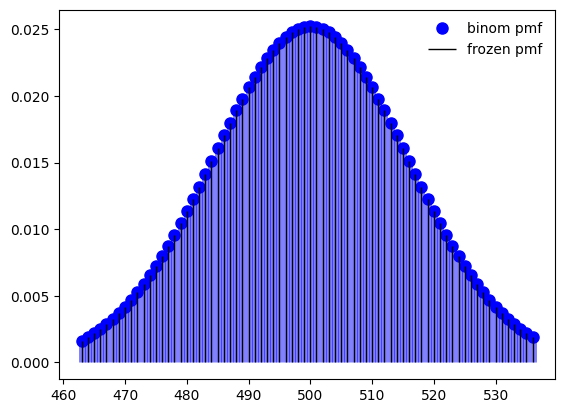

In [ ]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)

n, p = 1000, 0.5
mean, var, skew, kurt = binom.stats(n, p, moments='mvsk')

x = np.arange(binom.ppf(0.01, n, p),
              binom.ppf(0.99, n, p))
ax.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='binom pmf')
ax.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)

rv = binom(n, p)
ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')
ax.legend(loc='best', frameon=False)
plt.show()